<a href="https://colab.research.google.com/github/345bc/th-deep-learning/blob/main/BTTuan04_AUTOENCODERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AUTOENCODER

Nạp thư viện

In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

Nạp datasets

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape(len(x_train), np.prod(x_train.shape[1:]))
x_test = x_test.reshape(len(x_test), np.prod(x_test.shape[1:]))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


xây dựng mô hình auto encoder

In [3]:
from keras import regularizers

# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(
    encoding_dim,
    activity_regularizer=regularizers.l1(10e-5),
    activation='relu'
)(input_img)

# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

# This model maps an input to its encoded representation
encoder = keras.Model(input_img, encoded)

# This is our encoded (32-dimensional) input
encoded_input = keras.Input(shape=(encoding_dim,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

huấn luyện mô hình

In [4]:
# Cấu hình cách Autoencoder học
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Huấn luyện model
autoencoder.fit(
    x_train,       # dữ liệu đầu vào
    x_train,       # dữ liệu cần dự đoán lại chính nó
    epochs=100,
    batch_size=256,
    verbose=1,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0138 - loss: 0.6553 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0149 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0149 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0150 - loss: 0.3739 - val_acc

dự đoán ảnh

In [5]:
# Đưa ảnh test qua Encoder để nén
encoded_imgs = encoder.predict(x_test)


# Đưa dữ liệu đã nén qua Decoder để khôi phục ảnh
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


hien thi anh

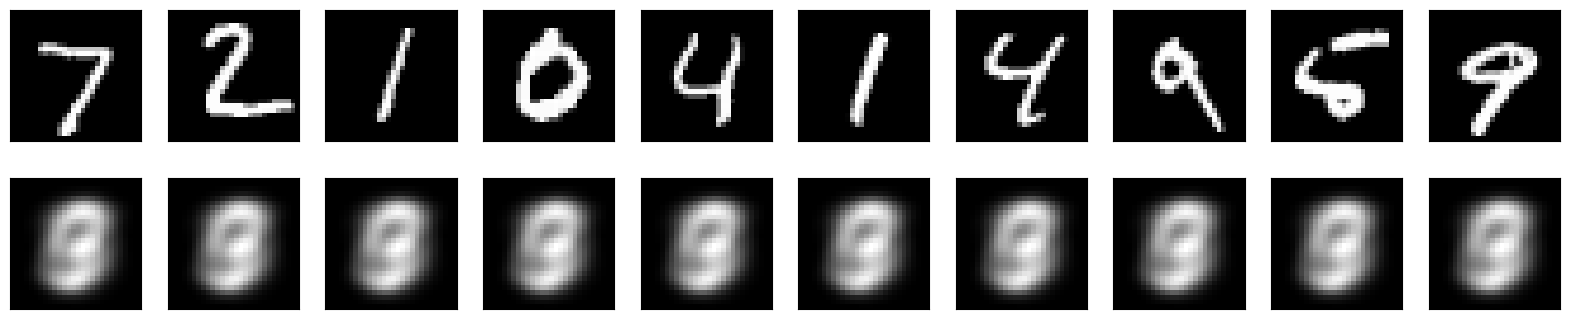

In [6]:
# Dùng Matplotlib để hiển thị ảnh
import matplotlib.pyplot as plt


# Số lượng ảnh muốn hiển thị
n = 10

# Tạo vùng hiển thị:
# 2 dòng, n cột
plt.figure(figsize=(20, 4))


for i in range(n):

    # =====================
    # HIỂN THỊ ẢNH GỐC
    # =====================
    ax = plt.subplot(2, n, i + 1)

    # x_test đang là 784 chiều
    # đổi lại thành ảnh 28x28 để hiển thị
    plt.imshow(
        x_test[i].reshape(28, 28)
    )

    # Hiển thị dạng ảnh xám
    plt.gray()


    # Ẩn trục x,y cho đẹp
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)



    # =====================
    # HIỂN THỊ ẢNH KHÔI PHỤC
    # =====================
    ax = plt.subplot(2, n, i + 1 + n)

    # decoded_imgs là ảnh được Decoder tạo lại
    plt.imshow(
        decoded_imgs[i].reshape(28, 28)
    )

    plt.gray()


    # Ẩn trục x,y
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)



# Hiển thị toàn bộ
plt.show()